## **Softmax Regression**

### **Topic Roadmap**

**1. Environment Setup and Data Loading**

**2. Data Preprocessing**

**3. Model Training**

**4. Model Evaluation and Probability Prediction**

**5. Decision Boundary Visualization**

### **Environment Setup and Data Loading**

Import standard data manipulation, machine learning, and visualization libraries. Load the built-in Iris dataset using the Seaborn library.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from mlxtend.plotting import plot_decision_regions

In [27]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### **Data Preprocessing**

Encode the categorical target labels into numeric formats required by the model. Isolate the specific independent features needed for visualization and model training, and split the data into training and testing sets.

In [28]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [29]:
df_selected = df[['sepal_length', 'petal_length', 'species']].copy()

X = df_selected.iloc[:, 0:2]
y = df_selected.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### **Model Training**

Initialize and fit the Logistic Regression classifier. When a target variable contains more than two classes, Scikit-Learn's Logistic Regression automatically operates as a multinomial Softmax Regression model.

In [30]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### **Model Evaluation and Probability Prediction**

Measure predictive performance using standard classification metrics. Utilize `predict_proba` to extract the probability distribution across all possible target classes for a specific query point.

In [31]:
y_pred = clf.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
display(pd.DataFrame(confusion_matrix(y_test, y_pred)))

Accuracy Score: 0.9666666666666667


,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [32]:
# Define a custom query point for sepal_length and petal_length
query = np.array([[3.4, 2.7]])

probabilities = clf.predict_proba(query)
predicted_class = clf.predict(query)

print("Class Probabilities:", probabilities)
print("Predicted Class:", predicted_class)

Class Probabilities: [[7.25865651e-01 2.73720718e-01 4.13631316e-04]]
Predicted Class: [0]


C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### **Decision Boundary Visualization**

Map the model's decision boundaries against the two input features utilizing the `plot_decision_regions` function from the `mlxtend` package.

C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


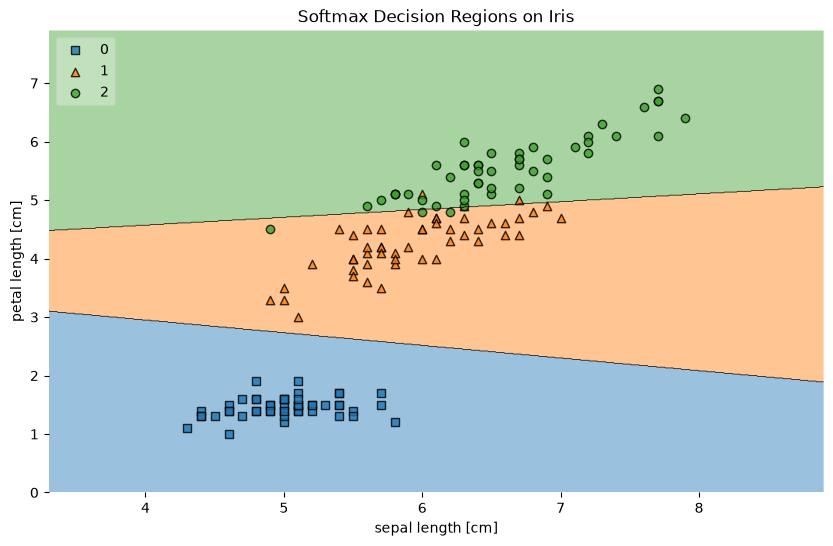

In [33]:
plt.figure(figsize=(10, 6))
plot_decision_regions(X.values, y.values, clf=clf, legend=2)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.title('Softmax Decision Regions on Iris')
plt.show()

### **Key Revision Notes**

* **Softmax Application**: Softmax Regression handles multi-class classification. It is deployed using the standard `LogisticRegression` module by extending the binary log-loss to cross-entropy loss.
* **Probability Distributions**: `predict_proba()` outputs an array representing the probability of the input belonging to each respective class. The predicted class corresponds to the highest probability value.
* **Data Visualization Constraints**: When utilizing `mlxtend` to plot decision regions, the visualizer can generally only handle two dimensions (features) at a time.